In [32]:
import pandas as pd

# Load dataset
df = pd.read_csv("data/Airline_review.csv")
df.head()


,Unnamed: 0,Airline Name,Overall_Rating,Review_Title,Review Date,Verified,Review,Aircraft,Type Of Traveller,Seat Type,Route,Date Flown,Seat Comfort,Cabin Staff Service,Food & Beverages,Ground Service,Inflight Entertainment,Wifi & Connectivity,Value For Money,Recommended
0,0,AB Aviation,9,"""pretty decent airline""",11th November 2019,True,Moroni to Moheli. Turned out to be a pretty ...,NaN,Solo Leisure,Economy Class,Moroni to Moheli,November 2019,4.0,5.0,4.0,4.0,NaN,NaN,3.0,yes
1,1,AB Aviation,1,"""Not a good airline""",25th June 2019,True,Moroni to Anjouan. It is a very small airline...,E120,Solo Leisure,Economy Class,Moroni to Anjouan,June 2019,2.0,2.0,1.0,1.0,NaN,NaN,2.0,no
2,2,AB Aviation,1,"""flight was fortunately short""",25th June 2019,True,Anjouan to Dzaoudzi. A very small airline an...,Embraer E120,Solo Leisure,Economy Class,Anjouan to Dzaoudzi,June 2019,2.0,1.0,1.0,1.0,NaN,NaN,2.0,no
3,3,Adria Airways,1,"""I will never fly again with Adria""",28th September 2019,False,Please do a favor yourself and do not fly wi...,NaN,Solo Leisure,Economy Class,Frankfurt to Pristina,September 2019,1.0,1.0,NaN,1.0,NaN,NaN,1.0,no
4,4,Adria Airways,1,"""it ruined our last days of holidays""",24th September 2019,True,Do not book a flight with this airline! My fr...,NaN,Couple Leisure,Economy Class,Sofia to Amsterdam via Ljubljana,September 2019,1.0,1.0,1.0,1.0,1.0,1.0,1.0,no


In [33]:
df.columns = df.columns.str.strip()

In [34]:
print(df.columns)

Index(['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title',
       'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller',
       'Seat Type', 'Route', 'Date Flown', 'Seat Comfort',
       'Cabin Staff Service', 'Food & Beverages', 'Ground Service',
       'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money',
       'Recommended'],
      dtype='object')


In [35]:
print(df.columns.tolist())

['Unnamed: 0', 'Airline Name', 'Overall_Rating', 'Review_Title', 'Review Date', 'Verified', 'Review', 'Aircraft', 'Type Of Traveller', 'Seat Type', 'Route', 'Date Flown', 'Seat Comfort', 'Cabin Staff Service', 'Food & Beverages', 'Ground Service', 'Inflight Entertainment', 'Wifi & Connectivity', 'Value For Money', 'Recommended']


In [36]:
print(df.shape)

(23171, 20)


In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23171 entries, 0 to 23170
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              23171 non-null  int64  
 1   Airline Name            23171 non-null  object 
 2   Overall_Rating          23171 non-null  object 
 3   Review_Title            23171 non-null  object 
 4   Review Date             23171 non-null  object 
 5   Verified                23171 non-null  bool   
 6   Review                  23171 non-null  object 
 7   Aircraft                7129 non-null   object 
 8   Type Of Traveller       19433 non-null  object 
 9   Seat Type               22075 non-null  object 
 10  Route                   19343 non-null  object 
 11  Date Flown              19417 non-null  object 
 12  Seat Comfort            19016 non-null  float64
 13  Cabin Staff Service     18911 non-null  float64
 14  Food & Beverages        14500 non-null

In [38]:
df.isnull().sum()

Unnamed: 0                    0
Airline Name                  0
Overall_Rating                0
Review_Title                  0
Review Date                   0
Verified                      0
Review                        0
Aircraft                  16042
Type Of Traveller          3738
Seat Type                  1096
Route                      3828
Date Flown                 3754
Seat Comfort               4155
Cabin Staff Service        4260
Food & Beverages           8671
Ground Service             4793
Inflight Entertainment    12342
Wifi & Connectivity       17251
Value For Money            1066
Recommended                   0
dtype: int64

In [39]:
# Convert ratings to numeric and handle missing values

rating_columns = [
    "Overall_Rating",
    "Seat Comfort",
    "Cabin Staff Service",
    "Food & Beverages",
    "Ground Service",
    "Inflight Entertainment",
    "Wifi & Connectivity",
    "Value For Money"
]

for col in rating_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(df[col].median())

    

In [40]:
# Categorical columns

categorical_cols = [
    "Aircraft",
    "Type Of Traveller",
    "Seat Type",
    "Route"
]

for col in categorical_cols:
    df[col] = df[col].fillna("Unknown")


In [41]:
# Remove duplicates

df.drop_duplicates(subset=[
    "Airline Name",
    "Review_Title",
    "Review Date",
    "Review"
], inplace=True)


In [42]:
# Text cleaning

import numpy as np
import re

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["Review_Title"] = df["Review_Title"].apply(clean_text)
df["Review"] = df["Review"].apply(clean_text)


In [43]:
# Combine text

df["full_review_text"] = df["Review_Title"] + " " + df["Review"]


In [44]:
# Severity label

def severity_label(row):
    rating = row["Overall_Rating"]
    text = row["full_review_text"]

    critical_keywords = ["cancel", "refund", "lost baggage", "unsafe", "never again"]
    high_keywords = ["delay", "rude", "bad service", "uncomfortable"]

    if any(word in text for word in critical_keywords):
        return "Critical"
    elif any(word in text for word in high_keywords):
        return "High"
    elif rating <= 4:
        return "High"
    elif rating <= 7:
        return "Medium"
    else:
        return "Low"

df["severity_label"] = df.apply(severity_label, axis=1)


In [45]:
# Encode severity

from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df["severity_id"] = le.fit_transform(df["severity_label"])


In [46]:
# Risk flag

def risk_flag(row):
    if row["Overall_Rating"] <= 4:
        return 1
    if str(row["Recommended"]).lower() == "no":
        return 1
    return 0

df["risk_flag"] = df.apply(risk_flag, axis=1)


In [28]:
# Save cleaned data

df.to_csv("data/cleaned_airline_reviews.csv", index=False)
print("Preprocessing Completed")


Preprocessing Completed


In [47]:
print(df["severity_label"].value_counts())


severity_label
High        13355
Critical     4907
Low          2910
Medium       1879
Name: count, dtype: int64


In [48]:

print(dict(zip(le.classes_, le.transform(le.classes_))))


{'Critical': np.int64(0), 'High': np.int64(1), 'Low': np.int64(2), 'Medium': np.int64(3)}


In [49]:
severity_map = {
    0: "Critical",
    1: "High",
    2: "Low",
    3: "Medium"
}


In [50]:
print(df["risk_flag"].value_counts())


risk_flag
1    17687
0     5364
Name: count, dtype: int64


In [51]:
# Exploratory Data Analysis'

In [52]:
# Load Cleaned Data for EDA

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("data/cleaned_airline_reviews.csv")


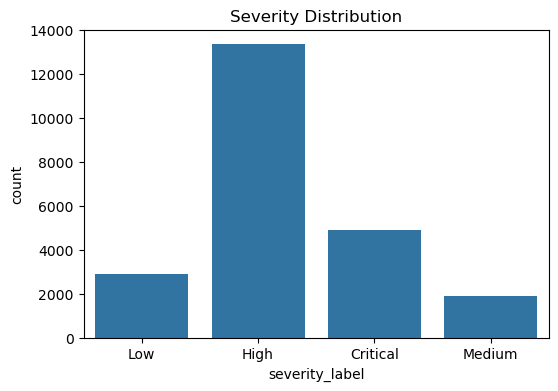

In [53]:
# Severity Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="severity_label", data=df)
plt.title("Severity Distribution")
plt.show()


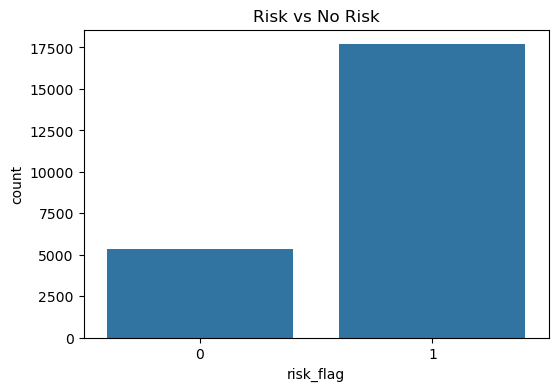

In [54]:
# Risk Distribution

plt.figure(figsize=(6,4))
sns.countplot(x="risk_flag", data=df)
plt.title("Risk vs No Risk")
plt.show()


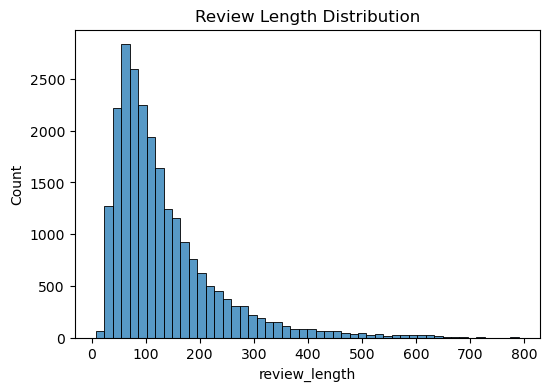

In [55]:
# Review Length Analysis

df["review_length"] = df["full_review_text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(6,4))
sns.histplot(df["review_length"], bins=50)
plt.title("Review Length Distribution")
plt.show()


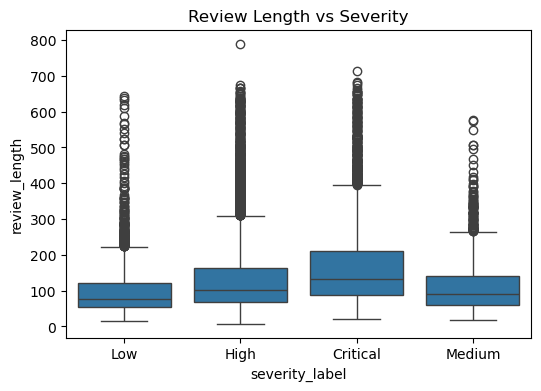

In [56]:
# Review length vs severity:

plt.figure(figsize=(6,4))
sns.boxplot(x="severity_label", y="review_length", data=df)
plt.title("Review Length vs Severity")
plt.show()


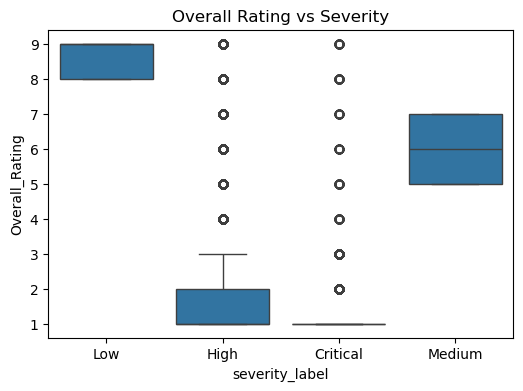

In [57]:
# Rating vs Severity

plt.figure(figsize=(6,4))
sns.boxplot(x="severity_label", y="Overall_Rating", data=df)
plt.title("Overall Rating vs Severity")
plt.show()


In [ ]:
# Wordcloud

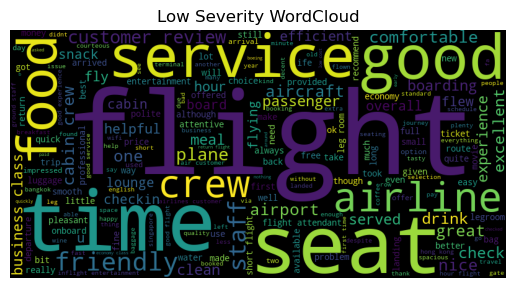

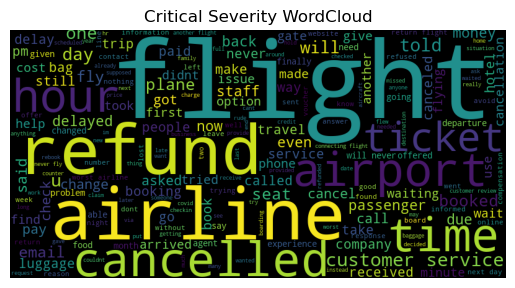

In [58]:
from wordcloud import WordCloud

low_text = " ".join(df[df["severity_label"]=="Low"]["full_review_text"])
critical_text = " ".join(df[df["severity_label"]=="Critical"]["full_review_text"])

wordcloud_low = WordCloud(width=800, height=400).generate(low_text)
wordcloud_critical = WordCloud(width=800, height=400).generate(critical_text)

plt.imshow(wordcloud_low)
plt.axis("off")
plt.title("Low Severity WordCloud")
plt.show()

plt.imshow(wordcloud_critical)
plt.axis("off")
plt.title("Critical Severity WordCloud")
plt.show()


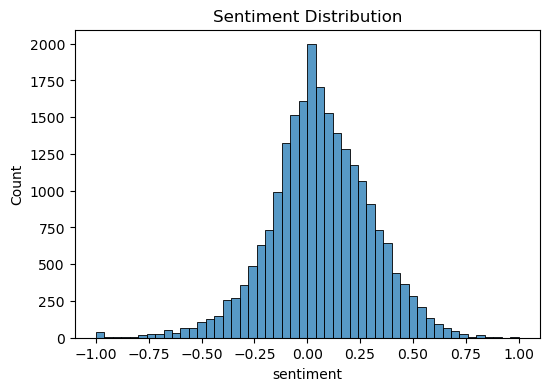

In [59]:
# Sentiment Analysis

from textblob import TextBlob

df["sentiment"] = df["full_review_text"].apply(lambda x: TextBlob(str(x)).sentiment.polarity)

plt.figure(figsize=(6,4))
sns.histplot(df["sentiment"], bins=50)
plt.title("Sentiment Distribution")
plt.show()


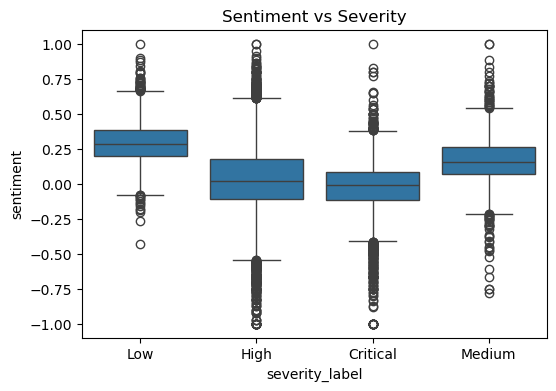

In [60]:
# Sentiment vs Severity:

plt.figure(figsize=(6,4))
sns.boxplot(x="severity_label", y="sentiment", data=df)
plt.title("Sentiment vs Severity")
plt.show()


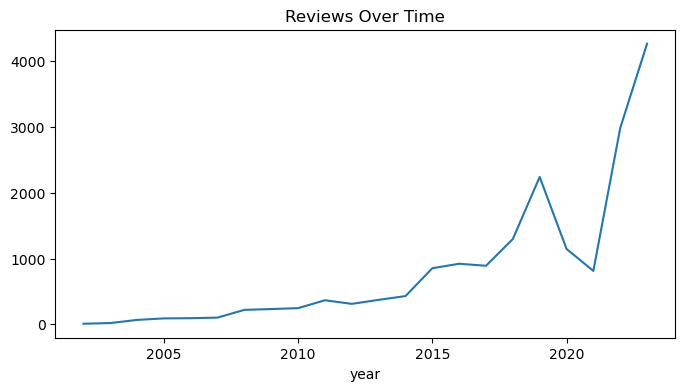

In [61]:
# Time Trend Analysis

df["Review Date"] = pd.to_datetime(df["Review Date"], errors='coerce')

df["year"] = df["Review Date"].dt.year

plt.figure(figsize=(8,4))
df.groupby("year").size().plot()
plt.title("Reviews Over Time")
plt.show()


In [62]:
# Prepare Data for ML Models

In [63]:
# Load cleaned dataset:

import pandas as pd

df = pd.read_csv("data/cleaned_airline_reviews.csv")


In [64]:
# Define features and targets:

X_text = df["full_review_text"]
y_severity = df["severity_id"]
y_risk = df["risk_flag"]


In [65]:
# TF-IDF Vectorization

from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2),
    stop_words="english"
)

X_tfidf = tfidf.fit_transform(X_text)


In [66]:
# Train/Test Split

from sklearn.model_selection import train_test_split

# Severity
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_tfidf, y_severity, test_size=0.2, random_state=42
)

# Risk
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_tfidf, y_risk, test_size=0.2, random_state=42
)


In [67]:
# Severity Classification Models

In [68]:
# Logistic Regression

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_s, y_train_s)

y_pred_lr = lr.predict(X_test_s)

print("Logistic Regression - Severity")
print(classification_report(y_test_s, y_pred_lr))


Logistic Regression - Severity
              precision    recall  f1-score   support

           0       0.99      0.76      0.86       961
           1       0.76      0.94      0.84      2683
           2       0.48      0.38      0.43       575
           3       0.44      0.10      0.16       392

    accuracy                           0.76      4611
   macro avg       0.67      0.54      0.57      4611
weighted avg       0.74      0.76      0.73      4611



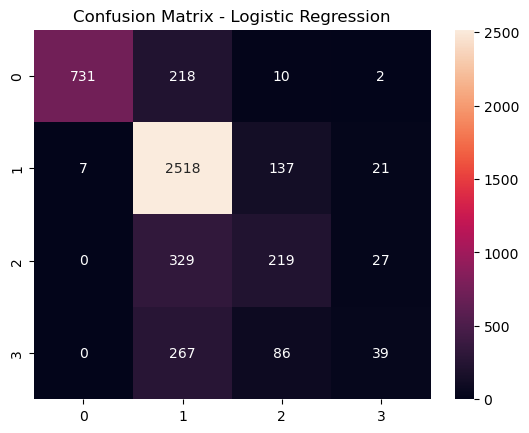

In [69]:
# Confusion Matrix Plots

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_s, y_pred_lr)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [70]:
# SVM

from sklearn.svm import LinearSVC

svm = LinearSVC()
svm.fit(X_train_s, y_train_s)

y_pred_svm = svm.predict(X_test_s)

print("SVM - Severity")
print(classification_report(y_test_s, y_pred_svm))


SVM - Severity
              precision    recall  f1-score   support

           0       0.99      0.85      0.91       961
           1       0.79      0.91      0.84      2683
           2       0.48      0.44      0.46       575
           3       0.31      0.14      0.19       392

    accuracy                           0.77      4611
   macro avg       0.64      0.58      0.60      4611
weighted avg       0.75      0.77      0.75      4611



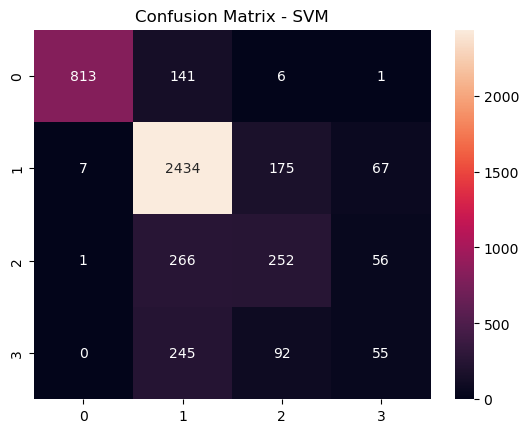

In [71]:
# Confusion Matrix Plots

cm = confusion_matrix(y_test_s, y_pred_svm)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - SVM")
plt.show()


In [72]:
# Naive Bayes

from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()
nb.fit(X_train_s, y_train_s)

y_pred_nb = nb.predict(X_test_s)

print("Naive Bayes - Severity")
print(classification_report(y_test_s, y_pred_nb))


Naive Bayes - Severity
              precision    recall  f1-score   support

           0       0.76      0.71      0.74       961
           1       0.74      0.84      0.78      2683
           2       0.46      0.52      0.49       575
           3       0.36      0.01      0.02       392

    accuracy                           0.70      4611
   macro avg       0.58      0.52      0.51      4611
weighted avg       0.68      0.70      0.67      4611



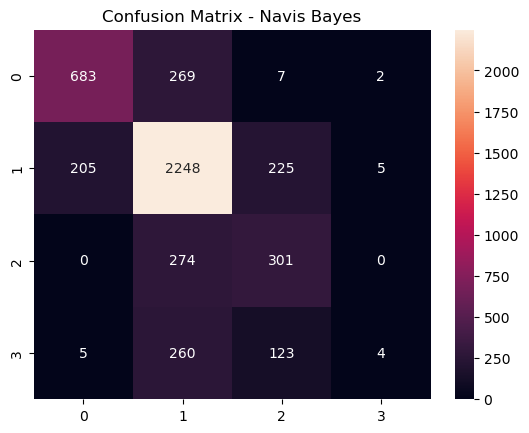

In [73]:
# Confusion Matrix Plots

cm = confusion_matrix(y_test_s, y_pred_nb)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Navis Bayes")
plt.show()


In [74]:
# Risk Classification Models

In [75]:
# Logistic Regression

lr_risk = LogisticRegression(max_iter=1000)
lr_risk.fit(X_train_r, y_train_r)

y_pred_lr_risk = lr_risk.predict(X_test_r)

print("Logistic Regression - Risk")
print(classification_report(y_test_r, y_pred_lr_risk))


Logistic Regression - Risk
              precision    recall  f1-score   support

           0       0.71      0.58      0.64      1078
           1       0.88      0.93      0.90      3533

    accuracy                           0.85      4611
   macro avg       0.79      0.75      0.77      4611
weighted avg       0.84      0.85      0.84      4611



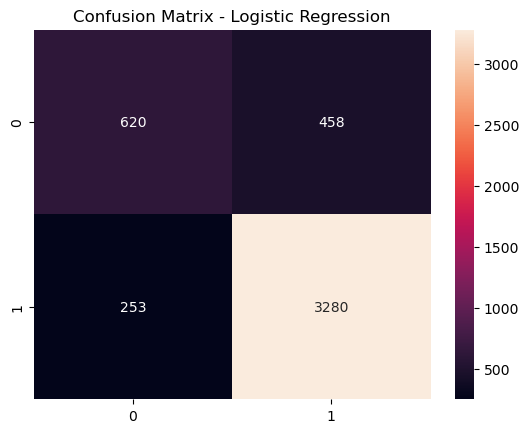

In [76]:
# Confusion Matrix Plots

cm = confusion_matrix(y_test_r, y_pred_lr_risk)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()


In [77]:
# Random Forest

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_train_r, y_train_r)

y_pred_rf = rf.predict(X_test_r)

print("Random Forest - Risk")
print(classification_report(y_test_r, y_pred_rf))


Random Forest - Risk
              precision    recall  f1-score   support

           0       0.71      0.46      0.56      1078
           1       0.85      0.94      0.89      3533

    accuracy                           0.83      4611
   macro avg       0.78      0.70      0.73      4611
weighted avg       0.82      0.83      0.82      4611



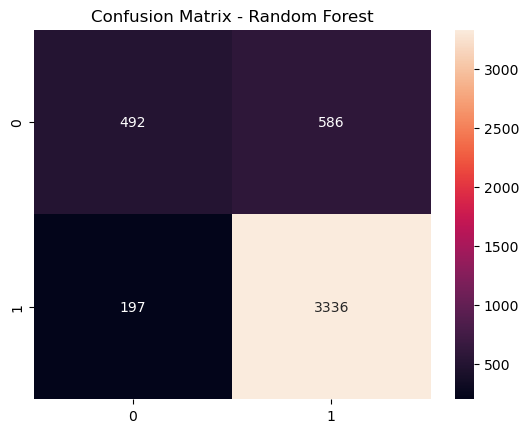

In [78]:
# Confusion Matrix Plots

cm = confusion_matrix(y_test_r, y_pred_rf)
sns.heatmap(cm, annot=True, fmt="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()


In [79]:
# Model Comparison Table

from sklearn.metrics import accuracy_score, f1_score

models = ["LogReg", "SVM", "NaiveBayes"]
preds = [y_pred_lr, y_pred_svm, y_pred_nb]

for name, pred in zip(models, preds):
    print(name)
    print("Accuracy:", accuracy_score(y_test_s, pred))
    print("F1 Score:", f1_score(y_test_s, pred, average="macro"))
    print("-------------")
    

LogReg
Accuracy: 0.7605725439167209
F1 Score: 0.5715983706292819
-------------
SVM
Accuracy: 0.7707655606159185
F1 Score: 0.6017761583714246
-------------
NaiveBayes
Accuracy: 0.7018000433745392
F1 Score: 0.5074411561469871
-------------


In [80]:
import os

os.makedirs("models", exist_ok=True)


In [81]:
# Save Models

import joblib

joblib.dump(lr, "models/severity_lr.pkl")
joblib.dump(svm, "models/severity_svm.pkl")
joblib.dump(nb, "models/severity_nb.pkl")
joblib.dump(rf, "models/risk_rf.pkl")
joblib.dump(tfidf, "models/tfidf.pkl")


['models/tfidf.pkl']

In [82]:
# Deep Learning Model

In [83]:
# Text Preparation - Tokenizer + Padding

import pandas as pd
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

df = pd.read_csv("data/cleaned_airline_reviews.csv")

texts = df["full_review_text"]
y_severity = df["severity_id"]
y_risk = df["risk_flag"]

# Tokenizer
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)

# Padding
X_pad = pad_sequences(sequences, maxlen=200)


In [84]:
# Train Test Split (DL)

from sklearn.model_selection import train_test_split

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_pad, y_severity, test_size=0.2, random_state=42
)

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_pad, y_risk, test_size=0.2, random_state=42
)


In [85]:
# Build BiLSTM Model (Severity)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional

model_severity = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(64, activation='relu'),
    Dense(4, activation='softmax')
])

model_severity.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_severity.build(input_shape=(None, 200))
model_severity.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding (Embedding)                │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional (Bidirectional)        │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │             260 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,387,332 (5.29 MB)

 Trainable params: 1,387,332 (5.29 MB)

 Non-trainable params: 0 (0.00 B)

In [86]:
# Train Model

model_severity.fit(
    X_train_s,
    y_train_s,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 43s 74ms/step - accuracy: 0.5793 - loss: 0.9434 - val_accuracy: 0.7126 - val_loss: 0.7010
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 41s 79ms/step - accuracy: 0.7262 - loss: 0.6539 - val_accuracy: 0.7787 - val_loss: 0.5804
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.7115 - loss: 0.6491 - val_accuracy: 0.7646 - val_loss: 0.6095
Epoch 4/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 37s 71ms/step - accuracy: 0.8112 - loss: 0.4698 - val_accuracy: 0.7842 - val_loss: 0.5855
Epoch 5/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 39s 76ms/step - accuracy: 0.8347 - loss: 0.4013 - val_accuracy: 0.7674 - val_loss: 0.6188


In [87]:
# Risk Model

model_risk = Sequential([
    Embedding(input_dim=10000, output_dim=128),
    Bidirectional(LSTM(64)),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model_risk.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_risk.build(input_shape=(None, 200))
model_risk.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)              │ (None, 200, 128)            │       1,280,000 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ bidirectional_1 (Bidirectional)      │ (None, 128)                 │          98,816 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 32)                  │           4,128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,382,977 (5.28 MB)

 Trainable params: 1,382,977 (5.28 MB)

 Non-trainable params: 0 (0.00 B)

In [88]:
# Train Model

model_risk.fit(
    X_train_r,
    y_train_r,
    epochs=5,
    batch_size=32,
    validation_split=0.1
)


Epoch 1/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - accuracy: 0.8168 - loss: 0.3760 - val_accuracy: 0.8297 - val_loss: 0.3361
Epoch 2/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 35s 67ms/step - accuracy: 0.8616 - loss: 0.2873 - val_accuracy: 0.8357 - val_loss: 0.3369
Epoch 3/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.8874 - loss: 0.2463 - val_accuracy: 0.8351 - val_loss: 0.3838
Epoch 4/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.9099 - loss: 0.2059 - val_accuracy: 0.8384 - val_loss: 0.4403
Epoch 5/5
519/519 ━━━━━━━━━━━━━━━━━━━━ 36s 69ms/step - accuracy: 0.9347 - loss: 0.1571 - val_accuracy: 0.8313 - val_loss: 0.5144


In [89]:
# Save Models

model_severity.save("models/dl_severity_model.keras")
model_risk.save("models/dl_risk_model.keras")


In [90]:
# Save Tokenizer

import pickle

with open("models/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)
    

In [91]:
# Transformer Model

In [92]:
# Prepare Data for Transformer

import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer
import torch

# Load data
df = pd.read_csv("data/cleaned_airline_reviews.csv")

# Reduce dataset for faster training
df = df.sample(3000, random_state=42)

X = df["full_review_text"]
y = df["severity_id"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [93]:
# Tokenization Using DistilBERT

tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)


In [94]:
# Create Dataset Class

class AirlineDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = AirlineDataset(train_encodings, y_train)
test_dataset = AirlineDataset(test_encodings, y_test)


In [95]:
# Load DistilBERT Model

from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=4
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [96]:
# Training Arguments

from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=100
)


In [97]:
# Trainer

from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)


In [98]:
# Train

trainer.train()


C:\Users\kthkr\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
100,0.895051


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=150, training_loss=0.8078608322143555, metrics={'train_runtime': 449.5115, 'train_samples_per_second': 5.339, 'train_steps_per_second': 0.334, 'total_flos': 79483274035200.0, 'train_loss': 0.8078608322143555, 'epoch': 1.0})

In [99]:
# Evaluate

import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred,zero_division=0))


C:\Users\kthkr\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.73
F1 Score: 0.5459406667072445
              precision    recall  f1-score   support

           0       0.99      0.83      0.90       122
           1       0.73      0.88      0.80       337
           2       0.45      0.53      0.49        77
           3       0.00      0.00      0.00        64

    accuracy                           0.73       600
   macro avg       0.54      0.56      0.55       600
weighted avg       0.67      0.73      0.69       600



In [100]:
# Save model

trainer.save_model("models/distilbert_severity")
tokenizer.save_pretrained("models/distilbert_severity")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/distilbert_severity\\tokenizer_config.json',
 'models/distilbert_severity\\tokenizer.json')

In [101]:
# Transformer Risk Model

In [102]:
import pandas as pd
from sklearn.model_selection import train_test_split
from transformers import DistilBertTokenizer
import torch

df = pd.read_csv("data/cleaned_airline_reviews.csv")
df = df.sample(3000, random_state=42)

X = df["full_review_text"]
y = df["risk_flag"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [103]:
tokenizer = DistilBertTokenizer.from_pretrained("distilbert-base-uncased")

train_encodings = tokenizer(
    X_train.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test.tolist(),
    truncation=True,
    padding=True,
    max_length=128
)


In [104]:
class AirlineDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.reset_index(drop=True)

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = AirlineDataset(train_encodings, y_train)
test_dataset = AirlineDataset(test_encodings, y_test)


In [105]:
from transformers import DistilBertForSequenceClassification

model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=2
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [106]:
from transformers import TrainingArguments

training_args = TrainingArguments(
    output_dir="./results_risk",
    num_train_epochs=1,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    logging_steps=100
)


In [107]:
from transformers import Trainer

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)


In [108]:
trainer.train()

C:\Users\kthkr\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
100,0.395821


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=150, training_loss=0.3764590199788411, metrics={'train_runtime': 454.283, 'train_samples_per_second': 5.283, 'train_steps_per_second': 0.33, 'total_flos': 79480439193600.0, 'train_loss': 0.3764590199788411, 'epoch': 1.0})

In [109]:
# Evaluate

import numpy as np
from sklearn.metrics import classification_report, accuracy_score, f1_score

predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred, average="macro"))
print(classification_report(y_test, y_pred,zero_division=0))


C:\Users\kthkr\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Accuracy: 0.8333333333333334
F1 Score: 0.7726411519514967
              precision    recall  f1-score   support

           0       0.63      0.68      0.66       139
           1       0.90      0.88      0.89       461

    accuracy                           0.83       600
   macro avg       0.77      0.78      0.77       600
weighted avg       0.84      0.83      0.84       600



In [110]:
trainer.save_model("models/distilbert_risk")
tokenizer.save_pretrained("models/distilbert_risk")


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/distilbert_risk\\tokenizer_config.json',
 'models/distilbert_risk\\tokenizer.json')

In [111]:
# Model Comparation table

In [112]:
# Severity Model Comparison Table

import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score, f1_score

severity_results = []

# Logistic Regression
severity_results.append([
    "Logistic Regression",
    accuracy_score(y_test_s, y_pred_lr),
    f1_score(y_test_s, y_pred_lr, average="macro")
])

# SVM
severity_results.append([
    "SVM",
    accuracy_score(y_test_s, y_pred_svm),
    f1_score(y_test_s, y_pred_svm, average="macro")
])

# Naive Bayes
severity_results.append([
    "Naive Bayes",
    accuracy_score(y_test_s, y_pred_nb),
    f1_score(y_test_s, y_pred_nb, average="macro")
])

# BiLSTM
y_pred_dl = np.argmax(model_severity.predict(X_test_s), axis=1)
loss, acc_dl = model_severity.evaluate(X_test_s, y_test_s)

severity_results.append([
    "BiLSTM",
    acc_dl,
    f1_score(y_test_s, y_pred_dl, average="macro")
])

# DistilBERT
predictions = trainer.predict(test_dataset)
y_pred_tr = np.argmax(predictions.predictions, axis=1)

severity_results.append([
    "DistilBERT",
    accuracy_score(y_test, y_pred_tr),
    f1_score(y_test, y_pred_tr, average="macro")
])

# Create table
severity_table = pd.DataFrame(
    severity_results,
    columns=["Model", "Accuracy", "F1 Score"]
)

print("Severity Classification Model Comparison")
print(severity_table)


145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - accuracy: 0.7460 - loss: 0.6757


C:\Users\kthkr\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Severity Classification Model Comparison
                 Model  Accuracy  F1 Score
0  Logistic Regression  0.760573  0.571598
1                  SVM  0.770766  0.601776
2          Naive Bayes  0.701800  0.507441
3               BiLSTM  0.746042  0.547395
4           DistilBERT  0.833333  0.772641


In [113]:
# Risk Model Comparison Table

risk_results = []

# Random Forest
risk_results.append([
    "Random Forest",
    accuracy_score(y_test_r, y_pred_rf),
    f1_score(y_test_r, y_pred_rf)
])

# BiLSTM Risk
y_pred_dl_risk = (model_risk.predict(X_test_r) > 0.5).astype(int)
loss_risk, acc_dl_risk = model_risk.evaluate(X_test_r, y_test_r)

risk_results.append([
    "BiLSTM",
    acc_dl_risk,
    f1_score(y_test_r, y_pred_dl_risk)
])

# DistilBERT Risk
predictions_risk = trainer.predict(test_dataset)
y_pred_tr_risk = np.argmax(predictions_risk.predictions, axis=1)

risk_results.append([
    "DistilBERT",
    accuracy_score(y_test, y_pred_tr_risk),
    f1_score(y_test, y_pred_tr_risk)
])

# Create table
risk_table = pd.DataFrame(
    risk_results,
    columns=["Model", "Accuracy", "F1 Score"]
)

print("\nRisk Classification Model Comparison")
print(risk_table)


145/145 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step
145/145 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.8222 - loss: 0.5084


C:\Users\kthkr\anaconda3\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



Risk Classification Model Comparison
           Model  Accuracy  F1 Score
0  Random Forest  0.830189  0.894970
1         BiLSTM  0.822164  0.882757
2     DistilBERT  0.833333  0.890110
